In [7]:
import numpy as np
import open3d as o3d
import laspy as lp
import os


In [2]:
file_path = r"./Data/Crankshaft HD.ply" # or the full path
if os.path.exists(file_path):
    print(f"File found: {file_path}")
else:
    print(f"File not found: {file_path}")


pcd_3od = o3d.io.read_point_cloud(file_path)
o3d.visualization.draw_geometries([pcd_3od])

File found: ./Data/Crankshaft HD.ply


In [3]:
las = lp.read(r"./Data/building.las")
points = np.vstack([las.x, las.y, las.z]).T


In [4]:
pcd_las_o3d = o3d.geometry.PointCloud()
pcd_las_o3d.points = o3d.utility.Vector3dVector(points)
o3d.visualization.draw_geometries([pcd_las_o3d])

In [6]:
curr_max_depth = 7
octree_las = o3d.geometry.Octree(max_depth = curr_max_depth)
octree_las.convert_from_point_cloud(pcd_las_o3d)
o3d.visualization.draw_geometries([octree_las])

# **Sub Samplin Stratigies**

Subsampling strategies for a point cloud are methods used to reduce the number of points in a point cloud while preserving the important geometric structure.

In [ ]:
las = lp.read(r"./Data/madison.las")
print(las.point_format.dimension_names)

points = np.vstack([las.x, las.y, las.z]).T

if all(c in las.point_format.dimension_names for c in ["red","green","blue"]):
    colors = np.vstack((las.red, las.green, las.blue)).T
    colors = colors / 65535.0   # normalize for visualization
else:
    print("No RGB data in this LAS file")
    colors = None
intensity = las.intensity
colors = np.vstack((intensity, intensity, intensity)).T
print(colors)

pcd_las_o3d = o3d.geometry.PointCloud()
pcd_las_o3d.points = o3d.utility.Vector3dVector(points)
o3d.visualization.draw_geometries([pcd_las_o3d])

<generator object PointFormat.dimension_names.<locals>.<genexpr> at 0x0000027538ABED50>
No RGB data in this LAS file
[[ 9  9  9]
 [41 41 41]
 [24 24 24]
 ...
 [87 87 87]
 [80 80 80]
 [95 95 95]]


**1. Point Cloud Decimation**

In [ ]:
factor = 160
decimated_points = points[::160]
len(decimated_points)

pcd_las_o3d = o3d.geometry.PointCloud()
pcd_las_o3d.points = o3d.utility.Vector3dVector(decimated_points)
o3d.visualization.draw_geometries([pcd_las_o3d])

**2. Point Cloud Voxel Grid**

In [ ]:
Voxel_size = 6
maxp = np.max(points , axis =0)
minp = np.min(points , axis =0)
# calculation to be how many voxels needed about each axis
nb_vox = np.ceil((maxp-minp)/Voxel_size)
print(nb_vox)



[834. 834.  31.]


In [ ]:
non_empty_voxels =( (points - minp) // Voxel_size).astype(int)
non_empty_voxel_keys, inverse, nb_pts_per_voxel= np.unique(((points - np.min(points, axis=0)) // Voxel_size).astype(int), axis=0, return_inverse=True, return_counts=True)
idx_pts_vox_sorted = np.argsort(inverse)
len(non_empty_voxel_keys)

1324957

In [23]:
'''
We store the voxels indicies as keys in a dict
store each related point to its key
compute each voxel barycenter and add it to a list
'''
voxel_grid={}
grid_barycenter,grid_candidate_center=[],[]
last_seen=0

for idx,vox in enumerate(non_empty_voxel_keys):
  voxel_grid[tuple(vox)]=points[idx_pts_vox_sorted[last_seen:last_seen+nb_pts_per_voxel[idx]]]
  grid_barycenter.append(np.mean(voxel_grid[tuple(vox)],axis=0))
  grid_candidate_center.append(voxel_grid[tuple(vox)][np.linalg.norm(voxel_grid[tuple(vox)]-np.mean(voxel_grid[tuple(vox)],axis=0),axis=1).argmin()])
  last_seen+=nb_pts_per_voxel[idx]


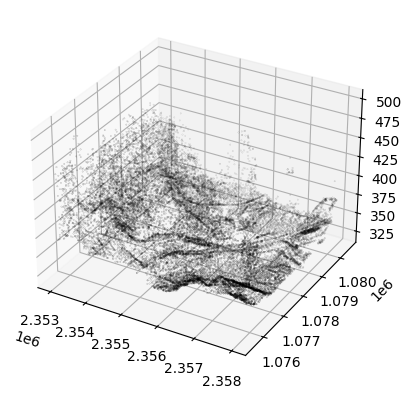

In [24]:

import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

ax = plt.axes(projection='3d')
ax.scatter(decimated_points[:,0], decimated_points[:,1], decimated_points[:,2], c = decimated_colors/65535, s=0.01)
plt.show()
     